# Product Clustering using K-Means

## Tujuan

Notebook ini bertujuan untuk mengelompokkan produk berdasarkan karakteristik numeriknya menggunakan algoritma **K-Means Clustering**.

Variabel yang digunakan meliputi:

- Average Price
- Rating
- Review Count
- Sold
- Seller Followers

Hasil clustering diharapkan dapat membantu mengidentifikasi kelompok produk yang memiliki karakteristik serupa sehingga dapat digunakan sebagai dasar analisis segmentasi produk.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df = pd.read_csv("../data/processed/ecommerce.csv")

df.head()

,keyword,product_id,product_name,url,currency,original_price_min,original_price_max,final_price_min,final_price_max,discount_percent,...,seller_name,seller_rating,seller_followers,seller_product,seller_response_rate,seller_response_time,seller_joined,price_avg,price_range,seller_age
0,headset,42531428335,VIVAN Earphone Headphone Headset In-Ear 3D Sub...,https://shopee.co.id/VIVAN-Earphone-Headphone-...,IDR,107000.0,107000.0,107000.0,107000.0,0,...,Vivan Official Shop,596400.0,716700.0,477.0,100.0,1,10 years ago,107000.0,0.0,10
1,headset,25117212844,Lenovo Thinkplus TH30 Headset Bluetooth V5.3 W...,https://shopee.co.id/Lenovo-Thinkplus-TH30-Hea...,IDR,240000.0,480000.0,142000.0,289000.0,53,...,Thinkplus Audio Store,56800.0,31400.0,235.0,100.0,2,33 months ago,215500.0,147000.0,33
2,headset,826361914,Xiaomi In-Ear Headphones Basic | Built-in Micr...,https://shopee.co.id/Xiaomi-In-Ear-Headphones-...,IDR,119000.0,119000.0,99000.0,99000.0,17,...,Xiaomi Official Store,3200000.0,3400000.0,341.0,95.0,2,8 years ago,99000.0,0.0,8
3,headset,40651424918,Pods Air Headset EarPods Kabel Earphone Handsf...,https://shopee.co.id/Pods-Air-Headset-EarPods-...,IDR,185165.0,185165.0,185165.0,185165.0,0,...,Pods Air,4100.0,3100.0,12.0,79.0,2,18 months ago,185165.0,0.0,18
4,headset,43662379094,Baseus Bass BH1 Lite Wireless Headphone Super ...,https://shopee.co.id/Baseus-Bass-BH1-Lite-Wire...,IDR,371420.0,371420.0,371420.0,371420.0,0,...,Baseus Official Shop,379900.0,249800.0,262.0,100.0,1,6 years ago,371420.0,0.0,6


## Feature Selection

Variabel yang digunakan pada proses clustering terdiri dari beberapa atribut numerik yang merepresentasikan karakteristik produk.

In [2]:
features = [
    "price_avg",
    "rating",
    "review_count",
    "sold",
    "seller_followers"
]
X = df[features].fillna(0)

X.head()

,price_avg,rating,review_count,sold,seller_followers
0,107000.0,4.9,13.0,68.0,716700.0
1,215500.0,4.9,10300.0,10000.0,31400.0
2,99000.0,4.9,63400.0,10000.0,3400000.0
3,185165.0,5.0,29.0,6000.0,3100.0
4,371420.0,4.9,750.0,2000.0,249800.0


## Feature Scaling

Karena setiap variabel memiliki satuan yang berbeda, dilakukan proses standardisasi menggunakan StandardScaler agar seluruh fitur memiliki skala yang sebanding.

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Menentukan Jumlah Cluster

Metode **Elbow Method** digunakan untuk menentukan jumlah cluster terbaik berdasarkan nilai inertia.

In [4]:
inertia = []

K = range(1,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

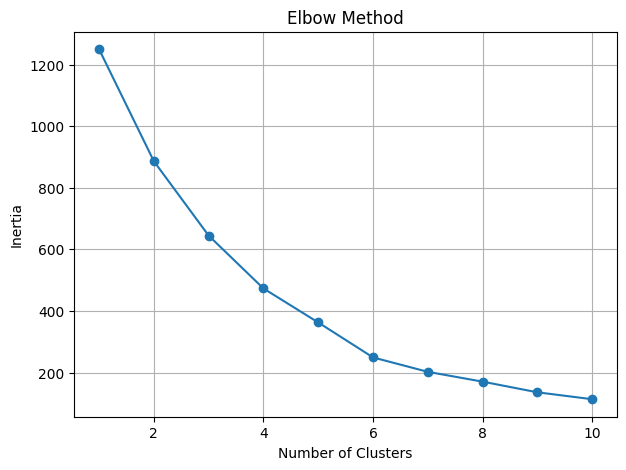

In [5]:
plt.figure(figsize=(7,5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

## Training K-Means

Berdasarkan hasil Elbow Method, jumlah cluster yang digunakan adalah **3 cluster**.

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

## Distribusi Cluster

Menampilkan jumlah data pada masing-masing cluster.

In [7]:
df["cluster"].value_counts().sort_index()

cluster
0      5
1    224
2     21
Name: count, dtype: int64

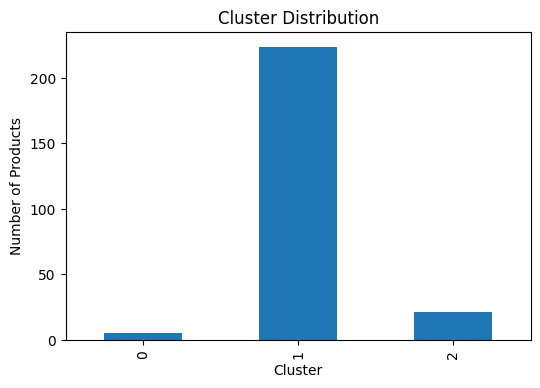

In [8]:
df["cluster"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Cluster Distribution")

plt.xlabel("Cluster")

plt.ylabel("Number of Products")

plt.show()

## Silhouette Score

Silhouette Score digunakan untuk mengukur kualitas hasil clustering.

Semakin mendekati nilai **1**, maka kualitas cluster semakin baik.

In [9]:
score = silhouette_score(
    X_scaled,
    df["cluster"]
)

print("Silhouette Score :", score)

Silhouette Score : 0.6493350945278942


## Visualisasi Cluster menggunakan PCA

Karena clustering dilakukan menggunakan lima variabel, maka digunakan **Principal Component Analysis (PCA)** untuk mereduksi dimensi menjadi dua komponen utama sehingga hasil clustering dapat divisualisasikan.

In [10]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:,0]

df["PCA2"] = X_pca[:,1]

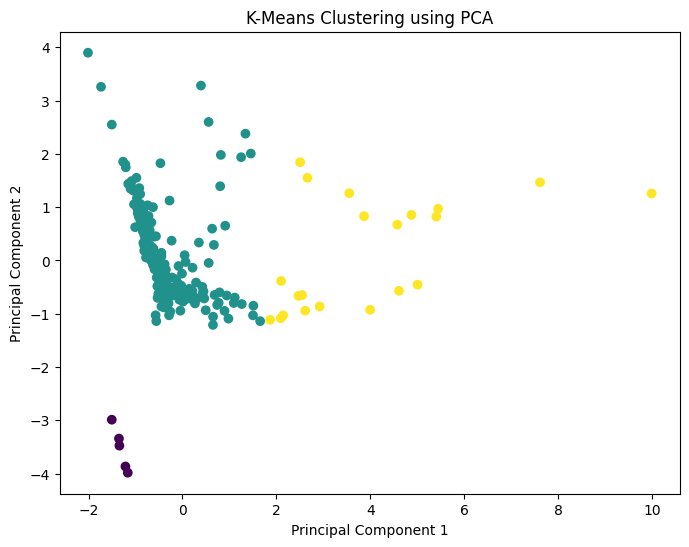

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["cluster"]
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("K-Means Clustering using PCA")

plt.show()

## Cluster Center

Menampilkan nilai rata-rata setiap cluster berdasarkan fitur asli.

In [12]:
cluster_center = pd.DataFrame(
    scaler.inverse_transform(
        kmeans.cluster_centers_
    ),
    columns=features
)

cluster_center

,price_avg,rating,review_count,sold,seller_followers
0,5.687600e+06,-8.881784e-16,2.273737e-13,2.000000,1.098920e+04
1,4.427654e+06,4.886161e+00,4.923839e+02,1100.464286,1.487300e+05
2,1.459778e+06,4.880952e+00,1.558095e+04,9333.333333,1.601310e+06


## Cluster Summary

Tahapan berikut digunakan untuk melihat karakteristik masing-masing cluster berdasarkan nilai rata-rata setiap fitur.

In [13]:
cluster_summary = df.groupby("cluster")[

    features

].mean()

cluster_summary

,price_avg,rating,review_count,sold,seller_followers
cluster,,,,,
0,5.687600e+06,NaN,0.000000,2.000000,1.098920e+04
1,4.427654e+06,4.886161,492.383929,1100.464286,1.487300e+05
2,1.459778e+06,4.880952,15580.952381,9333.333333,1.601310e+06


## Visualisasi Karakteristik Cluster

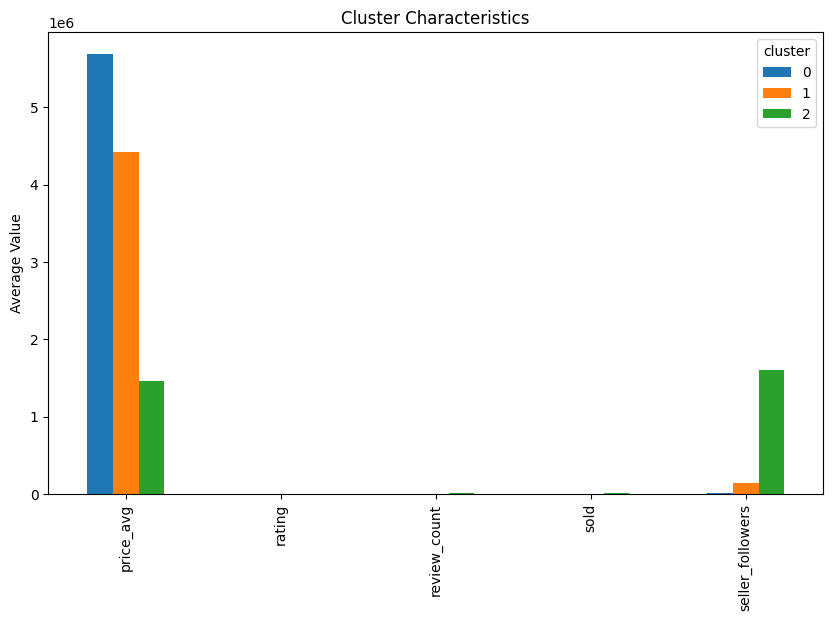

In [14]:
cluster_summary.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Cluster Characteristics")

plt.ylabel("Average Value")

plt.show()

## Simpan Dataset

Dataset hasil clustering disimpan untuk digunakan pada tahap analisis selanjutnya.

In [15]:
df.to_csv(
    "../data/processed/ecommerce_cluster.csv",
    index=False
)

print("Dataset berhasil disimpan.")

Dataset berhasil disimpan.
